In [1]:
import pandas as pd

In [2]:
file_path = "youth_employment.xlsx"
df = pd.read_excel(file_path, sheet_name="년도별 정리")

In [3]:
print(df)
print(df.shape)
print(df.columns)

       시도별   권역         2022         2023         2024      2025       변화폭
0    서울특별시  수도권    51.525000    51.825000    51.175000    49.100    -2.425
1    인천광역시  수도권    50.600000    49.175000    47.450000    44.775    -5.825
2      경기도  수도권    49.975000    49.875000    49.450000    46.675      -3.3
3    부산광역시   지방    42.000000    43.875000    46.125000    44.100       2.1
4    대구광역시   지방    41.225000    42.350000    37.475000    39.350    -1.875
5     전라북도   지방    38.600000    38.825000    38.025000    37.975    -0.625
6      NaN  NaN          NaN          NaN          NaN       NaN       NaN
7      NaN  NaN          NaN          NaN          NaN       NaN       NaN
8       평균   권역  2022.000000  2023.000000  2024.000000  2025.000       변화폭
9   수도권 평균  수도권    50.700000    50.291667    49.358333    46.850     -3.85
10   지방 평균   지방    40.608333    41.683333    40.541667    40.475 -0.133333
(11, 7)
Index(['시도별', '권역', 2022, 2023, 2024, 2025, '변화폭'], dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시도별     9 non-null      object 
 1   권역      9 non-null      object 
 2   2022    9 non-null      float64
 3   2023    9 non-null      float64
 4   2024    9 non-null      float64
 5   2025    9 non-null      float64
 6   변화폭     9 non-null      object 
dtypes: float64(4), object(3)
memory usage: 748.0+ bytes


In [5]:
df.isna().sum() # 결측값 확인

시도별     2
권역      2
2022    2
2023    2
2024    2
2025    2
변화폭     2
dtype: int64

In [6]:
# 완전 빈 행 삭제
df = df.dropna(how="all").reset_index(drop=True)

# 중복 헤더 행 삭제
df = df[df["변화폭"] != "변화폭"].reset_index(drop=True)

df

,시도별,권역,2022,2023,2024,2025,변화폭
0,서울특별시,수도권,51.525000,51.825000,51.175000,49.100,-2.425
1,인천광역시,수도권,50.600000,49.175000,47.450000,44.775,-5.825
2,경기도,수도권,49.975000,49.875000,49.450000,46.675,-3.3
3,부산광역시,지방,42.000000,43.875000,46.125000,44.100,2.1
4,대구광역시,지방,41.225000,42.350000,37.475000,39.350,-1.875
5,전라북도,지방,38.600000,38.825000,38.025000,37.975,-0.625
6,수도권 평균,수도권,50.700000,50.291667,49.358333,46.850,-3.85
7,지방 평균,지방,40.608333,41.683333,40.541667,40.475,-0.133333


In [7]:
# 3. 숫자형 변환
num_cols = [2022, 2023, 2024, 2025, "변화폭"]

df["변화폭"] = pd.to_numeric(df["변화폭"], errors="coerce")    
df[num_cols] = df[num_cols].round(2)

df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시도별     8 non-null      object 
 1   권역      8 non-null      object 
 2   2022    8 non-null      float64
 3   2023    8 non-null      float64
 4   2024    8 non-null      float64
 5   2025    8 non-null      float64
 6   변화폭     8 non-null      float64
dtypes: float64(5), object(2)
memory usage: 580.0+ bytes


In [8]:
df

,시도별,권역,2022,2023,2024,2025,변화폭
0,서울특별시,수도권,51.53,51.82,51.18,49.10,-2.43
1,인천광역시,수도권,50.60,49.18,47.45,44.78,-5.83
2,경기도,수도권,49.98,49.88,49.45,46.68,-3.30
3,부산광역시,지방,42.00,43.88,46.12,44.10,2.10
4,대구광역시,지방,41.22,42.35,37.48,39.35,-1.88
5,전라북도,지방,38.60,38.83,38.02,37.98,-0.62
6,수도권 평균,수도권,50.70,50.29,49.36,46.85,-3.85
7,지방 평균,지방,40.61,41.68,40.54,40.47,-0.13


In [9]:
df["권역"] = df["권역"].str.replace(" ", "")

df_city = df[~df["시도별"].str.contains("평균")].copy()
df_region = df[df["시도별"].str.contains("평균")].copy()

df_city = df_city.sort_values("변화폭")

df_city
df_region

,시도별,권역,2022,2023,2024,2025,변화폭
6,수도권 평균,수도권,50.70,50.29,49.36,46.85,-3.85
7,지방 평균,지방,40.61,41.68,40.54,40.47,-0.13


In [10]:
df_region

,시도별,권역,2022,2023,2024,2025,변화폭
6,수도권 평균,수도권,50.70,50.29,49.36,46.85,-3.85
7,지방 평균,지방,40.61,41.68,40.54,40.47,-0.13


In [11]:
df_city = df_city.sort_values("변화폭")
df_city[["시도별", "권역", "변화폭"]]

,시도별,권역,변화폭
1,인천광역시,수도권,-5.83
2,경기도,수도권,-3.30
0,서울특별시,수도권,-2.43
4,대구광역시,지방,-1.88
5,전라북도,지방,-0.62
3,부산광역시,지방,2.10


In [12]:
# 인천광역시는 분석 대상 지역 중 고용률 하락폭이 가장 크게 나타났다.
# 수도권에서는 서울특별시의 하락폭이 가장 작았고, 지방에서는 대구광역시의 하락폭이 가장 컸다.
# 부산광역시는 분석 대상 6개 지역 중 2022년 대비 2025년 고용률이 유일하게 상승하였다.

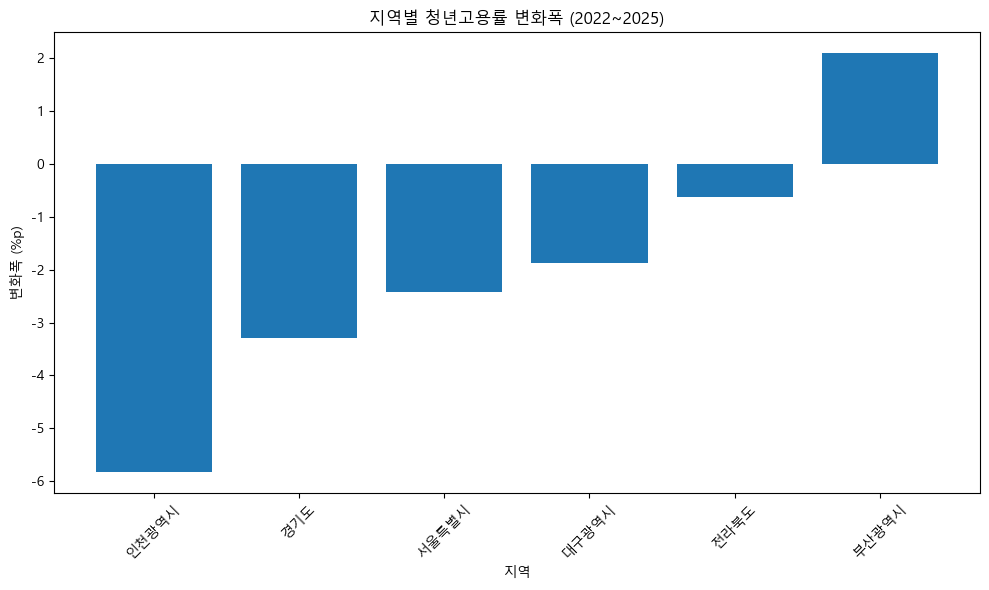

In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 6))
plt.bar(df_city["시도별"], df_city["변화폭"])
plt.title("지역별 청년고용률 변화폭 (2022~2025)")
plt.xlabel("지역")
plt.ylabel("변화폭 (%p)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# 그래프를 통해서 한눈에 어느지역이 가장 떨어졌는지 어느 지역이 올랐는지 볼 수 있다.

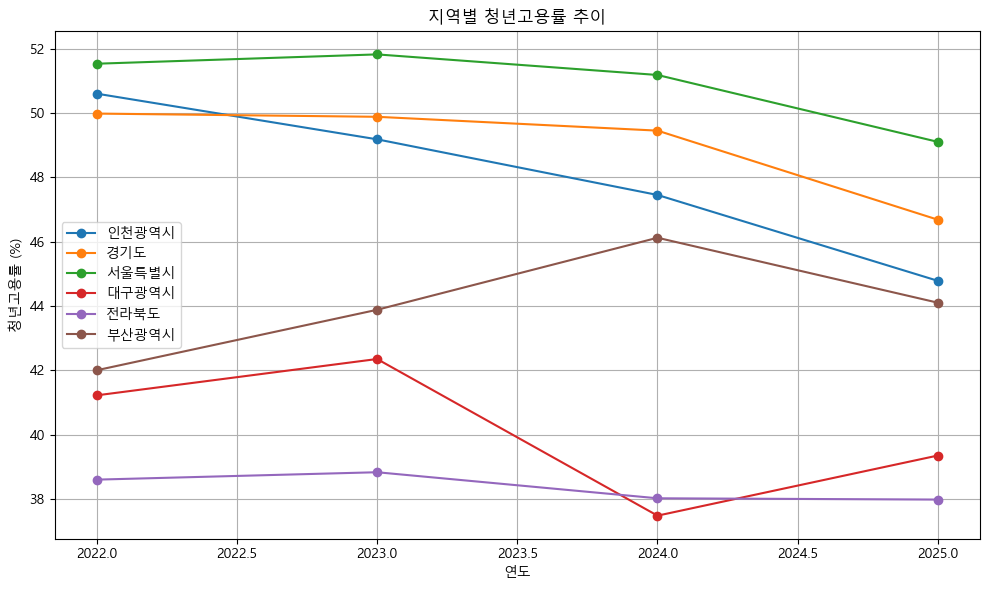

In [15]:
years = [2022, 2023, 2024, 2025]

plt.figure(figsize=(10, 6))

for i in range(len(df_city)):
    plt.plot(years, df_city.iloc[i][years], marker="o", label=df_city.iloc[i]["시도별"])

plt.title("지역별 청년고용률 추이")
plt.xlabel("연도")
plt.ylabel("청년고용률 (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# 연도별 증감 추이를 한눈에 확인할 수 있다.
# 인천광역시의 하락폭이 가장 컸지만, 2025년 고용률은 부산광역시, 대구광역시, 전라북도보다 높다.
# 인천광역시는 분석 기간 동안 지속적으로 하락했으며, 대구광역시는 2024년에 최저치를 기록하였다.

In [17]:
# 변동성 계산
years = [2022, 2023, 2024, 2025]

df_city["변동성"] = df_city[years].std(axis=1).round(2)

print(df_city[["시도별", "변화폭", "변동성"]])

     시도별   변화폭   변동성
1  인천광역시 -5.83  2.50
2    경기도 -3.30  1.56
0  서울특별시 -2.43  1.23
4  대구광역시 -1.88  2.14
5   전라북도 -0.62  0.42
3  부산광역시  2.10  1.68


In [18]:
df_city[["시도별", 2025]].sort_values(2025) # 고용률이 낮은 지역순

,시도별,2025
5,전라북도,37.98
4,대구광역시,39.35
3,부산광역시,44.10
1,인천광역시,44.78
2,경기도,46.68
0,서울특별시,49.10


In [19]:
# 변동성 계산
years = [2022, 2023, 2024, 2025]
df_city["변동성"] = df_city[years].std(axis=1).round(2)

# 위험할수록 큰 점수 부여
df_city["수준점수"] = df_city[2025].rank(ascending=False)      # 2025 낮을수록 큰 점수
df_city["하락점수"] = df_city["변화폭"].rank(ascending=False)   # 변화폭 낮을수록 큰 점수
df_city["변동성점수"] = df_city["변동성"].rank(ascending=True)  # 변동성 클수록 큰 점수

# 최종 리스크 점수
df_city["리스크점수"] = (
    df_city["수준점수"] +
    df_city["하락점수"] +
    df_city["변동성점수"]
).round(2)

# 위험할수록 위에 오게 정렬
print(
    df_city[["시도별", 2025, "변화폭", "변동성", "수준점수", "하락점수", "변동성점수", "리스크점수"]]
    .sort_values("리스크점수", ascending=False)
)

     시도별   2025   변화폭   변동성  수준점수  하락점수  변동성점수  리스크점수
1  인천광역시  44.78 -5.83  2.50   3.0   6.0    6.0   15.0
4  대구광역시  39.35 -1.88  2.14   5.0   3.0    5.0   13.0
2    경기도  46.68 -3.30  1.56   2.0   5.0    3.0   10.0
5   전라북도  37.98 -0.62  0.42   6.0   2.0    1.0    9.0
3  부산광역시  44.10  2.10  1.68   4.0   1.0    4.0    9.0
0  서울특별시  49.10 -2.43  1.23   1.0   4.0    2.0    7.0


In [20]:
df_city["위험등급"] = pd.qcut(
    df_city["리스크점수"],
    q=3,
    labels=["저위험", "중위험", "고위험"]
)

df_city[["시도별", "리스크점수", "위험등급"]].sort_values("리스크점수", ascending=False)

,시도별,리스크점수,위험등급
1,인천광역시,15.0,고위험
4,대구광역시,13.0,고위험
2,경기도,10.0,중위험
5,전라북도,9.0,저위험
3,부산광역시,9.0,저위험
0,서울특별시,7.0,저위험


In [21]:
years = [2022, 2023, 2024, 2025]

df_city["변동성"] = df_city[years].std(axis=1).round(2)

df_city[["시도별", 2025, "변화폭", "변동성"]]

,시도별,2025,변화폭,변동성
1,인천광역시,44.78,-5.83,2.50
2,경기도,46.68,-3.30,1.56
0,서울특별시,49.10,-2.43,1.23
4,대구광역시,39.35,-1.88,2.14
5,전라북도,37.98,-0.62,0.42
3,부산광역시,44.10,2.10,1.68


In [22]:
result = df_city[
    [
        "시도별", 
        "권역", 
        2025, 
        "변화폭", 
        "변동성", 
        "수준점수",
        "하락점수",
        "변동성점수",
        "리스크점수", 
        "위험등급"
    ]
].sort_values("리스크점수", ascending=False)

result

,시도별,권역,2025,변화폭,변동성,수준점수,하락점수,변동성점수,리스크점수,위험등급
1,인천광역시,수도권,44.78,-5.83,2.50,3.0,6.0,6.0,15.0,고위험
4,대구광역시,지방,39.35,-1.88,2.14,5.0,3.0,5.0,13.0,고위험
2,경기도,수도권,46.68,-3.30,1.56,2.0,5.0,3.0,10.0,중위험
5,전라북도,지방,37.98,-0.62,0.42,6.0,2.0,1.0,9.0,저위험
3,부산광역시,지방,44.10,2.10,1.68,4.0,1.0,4.0,9.0,저위험
0,서울특별시,수도권,49.10,-2.43,1.23,1.0,4.0,2.0,7.0,저위험


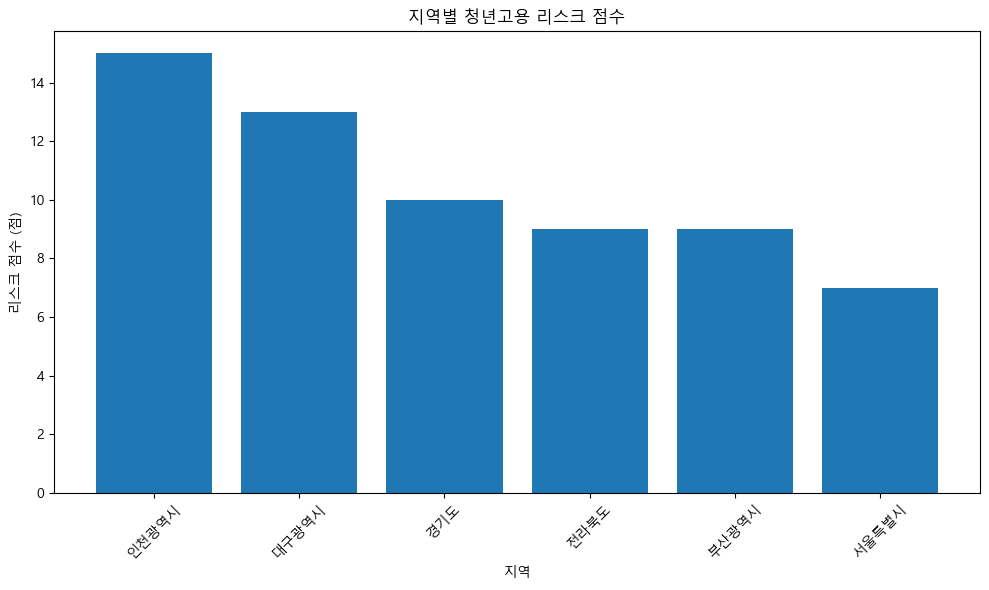

In [23]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

risk_df = result.copy()

plt.figure(figsize=(10, 6))
plt.bar(risk_df["시도별"], risk_df["리스크점수"])
plt.title("지역별 청년고용 리스크 점수")
plt.xlabel("지역")
plt.ylabel("리스크 점수 (점)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("risk_score_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
result.to_csv("youth_employment_risk_result.csv", index=False, encoding="utf-8-sig")